In [2]:
import numpy as np
import xarray as xr

# cartopy for plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import xarray as xr
import numpy as np
from dask.delayed import Delayed
from xmhw.identify import (
    land_check,
    add_doy,
    get_calendar,
    runavg,
    window_roll,
    calculate_seas,
    annotate_ds,
)
# -------- paths --------
ERA5_PATH   = "/Users/luty8/MHW_Project/data/base/era5/era5_atm_daily_0p25_GoM_1982-2024_v1.nc"
EVENTS_PATH = "/Users/luty8/MHW_Project/data/core/oisst/mhw_basin_detrended_1982-2024_xmhw.nc"
LABELS_PATH = "/Users/luty8/MHW_Project/data/core/eof_kmeans/detrend_labels_K4_1982-2024.nc"

# -------- fast2 dependency --------


# -------- periods (match your script) --------
CLIM_START, CLIM_END   = 1982, 2011
TREND_START, TREND_END = 1982, 2024

# -------- bulk constants --------
AIR_DENSITY = 1.225
LATENT_HEAT_VAP = 2.5e6
BULK_TRANSFER_COEFF = 1.2e-3

# IMPORTANT: ERA5 avg_slhtf is "downward positive" per your statement
SCALE = -(AIR_DENSITY * LATENT_HEAT_VAP * BULK_TRANSFER_COEFF)  # negative sign
SCALE


-3674.9999999999995

In [3]:
def area_mean(da: xr.DataArray, dims=("lat","lon")) -> xr.DataArray:
    w = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(w).mean(dims)

def map_event_times_to_era5_indices(ds_time: xr.DataArray,
                                   t_start: xr.DataArray,
                                   t_peak: xr.DataArray):
    """
    Map event time_start/time_peak to nearest indices on ds_time.
    Returns numpy arrays idx_start, idx_peak of length n_events.
    """
    t_era5 = ds_time.values

    def nearest_index(t):
        # t is numpy datetime64
        return int(np.argmin(np.abs(t_era5 - t)))

    idx_s = np.array([nearest_index(t) for t in t_start.values], dtype=int)
    idx_p = np.array([nearest_index(t) for t in t_peak.values], dtype=int)
    return idx_s, idx_p


In [4]:
def seasonal_climatology_fast2(
    temp: xr.DataArray,
    tdim: str = "time",
    climatologyPeriod=None,
    windowHalfWidth: int = 5,
    smooth: bool = True,
    smoothWidth: int = 31,
    tstep: bool = False,
) -> xr.Dataset:
    """
    更接近 xmhw.calc_clim 的季节均值算法：
      1. 先在时间维上做 ±windowHalfWidth 的滑动平均；
      2. 再按 day-of-year 做 climatology；
      3. 再用 runavg 做 31 天平滑。
    """

    # 1) 选 climatology 时间段
    if climatologyPeriod is not None and all(climatologyPeriod):
        temp = temp.sel(
            {
                tdim: slice(
                    f"{climatologyPeriod[0]}-01-01",
                    f"{climatologyPeriod[1]}-12-31",
                )
            }
        )

    time = temp[tdim]
    N = time.size
    width = 2 * windowHalfWidth + 1

    if N < width:
        raise ValueError("time length is too short for the given windowHalfWidth")

    # 2) 在时间维上做滑动平均（只保留窗口完整的点）
    #    min_periods=width 等价于 xmhw 对不完整窗口的 drop
    rolling_mean = temp.rolling({tdim: width}, center=True, min_periods=width).mean()

    # 3) 加 day-of-year 坐标，并按 doy 做 climatology
    doy = rolling_mean[tdim].dt.dayofyear
    # 关键修正：给坐标传入 (dims, data)，而不是整个 DataArray 对象
    rolling_mean = rolling_mean.assign_coords(
        doy=(tdim, doy.data)
    )

    # groupby('doy') 对时间维取平均，相当于 xmhw 的 calculate_seas
    seas = rolling_mean.groupby("doy").mean(dim=tdim, skipna=True)

    # 4) Feb 29 处理：和 xmhw 一样，用 59/60/61 的平均替代 60
    if not tstep and 60 in seas["doy"].values:
        feb29_val = seas.sel(doy=[59, 60, 61]).mean(dim="doy")
        seas = seas.where(seas["doy"] != 60, feb29_val)

    # 5) 31 天 running mean 平滑（和 xmhw 的 runavg 一样）
    if smooth:
        if smoothWidth % 2 == 0:
            raise ValueError("smoothWidth must be odd")
        seas = runavg(seas, smoothWidth)
    if isinstance(seas, Delayed):
        seas = seas.compute()
    # 6) 打包成 Dataset
    ds = seas.to_dataset(name="seasonal")

    start_year = int(time[0].dt.year)
    end_year = int(time[-1].dt.year)
    ds.attrs["method"] = (
        "Seasonal climatology (mean) via rolling-then-climatology:\n"
        f"  period {start_year}-{end_year}, "
        f"windowHalfWidth={windowHalfWidth}, smoothWidth={smoothWidth};\n"
        "  designed to mimic xmhw.calc_clim(seas) but vectorized."
    )

    return ds

In [5]:
ds = xr.open_dataset(ERA5_PATH)

if "date" in ds.dims:
    ds = ds.rename({"date":"time"})
if "latitude" in ds.dims:
    ds = ds.rename({"latitude":"lat"})
if "longitude" in ds.dims:
    ds = ds.rename({"longitude":"lon"})

ds


<xarray.Dataset> Size: 8GB
Dimensions:      (time: 15706, lat: 57, lon: 93)
Coordinates:
    number       int64 8B ...
  * lat          (lat) float64 456B 31.0 30.75 30.5 30.25 ... 17.5 17.25 17.0
  * lon          (lon) float64 744B -100.0 -99.75 -99.5 ... -77.5 -77.25 -77.0
    year         (time) int64 126kB ...
  * time         (time) datetime64[ns] 126kB 1982-01-01 ... 2024-12-31
Data variables: (12/23)
    avg_cpr      (time, lat, lon) float32 333MB ...
    avg_lsprate  (time, lat, lon) float32 333MB ...
    avg_iews     (time, lat, lon) float32 333MB ...
    avg_ie       (time, lat, lon) float32 333MB ...
    avg_inss     (time, lat, lon) float32 333MB ...
    avg_rorwe    (time, lat, lon) float32 333MB ...
    ...           ...
    msl          (time, lat, lon) float32 333MB ...
    sst          (time, lat, lon) float32 333MB ...
    sp           (time, lat, lon) float32 333MB ...
    tcc          (time, lat, lon) float32 333MB ...
    wind_speed   (time, lat, lon) float32 333MB ...
    avg_tprate   (time, lat, lon) float32 333MB ...
Attributes: (12/15)
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             ECMWF
    history:                 2025-09-23T20:13 GRIB to CDM+CF via cfgrib-0.9.1...
    ...                      ...
    temporal_resolution:     daily
    original_resolution:     hourly
    processing_method:       Daily mean calculated from 24 hourly values
    processing_date:         2025-10-09T23:24:51.087482
    year_range:              1982-2024
    contact:                 MHW analysis project

In [6]:
ev = xr.open_dataset(EVENTS_PATH)
lb = xr.open_dataset(LABELS_PATH)

# Attach cluster label by event order (0..N-1)
n_ev = ev.dims["events"]
assert lb.dims["event"] == n_ev, "Label file event count != ev events count."

ev = ev.assign_coords(event_id=("events", np.arange(n_ev)))
lb2 = lb.rename({"event": "event_id"})

# ---- swap label 1 and 2 ----
raw_labels = lb2["cluster_label_K4"].sel(event_id=ev["event_id"]).values
swapped_labels = raw_labels.copy()
swapped_labels[raw_labels == 1] = 2
swapped_labels[raw_labels == 2] = 1

ev = ev.assign_coords(
    cluster_label_K4=("events", swapped_labels)
)

# Map time_start/time_peak to ERA5 indices (robust against index mismatch)
idx_start_era5, idx_peak_era5 = map_event_times_to_era5_indices(
    ds["time"], ev["time_start"], ev["time_peak"]
)

# quick sanity check: print a few events
for i in np.random.choice(n_ev, size=5, replace=False):
    s = idx_start_era5[i]
    p = idx_peak_era5[i]
    print(
        "event#", i,
        "ERA5_start", ds["time"].isel(time=s).values, "xmhw_start", ev["time_start"].isel(events=i).values,
        "| ERA5_peak", ds["time"].isel(time=p).values, "xmhw_peak", ev["time_peak"].isel(events=i).values
    )


event# 90 ERA5_start 2020-03-18T00:00:00.000000000 xmhw_start 2020-03-18T12:00:00.000000000 | ERA5_peak 2020-04-10T00:00:00.000000000 xmhw_peak 2020-04-10T12:00:00.000000000
event# 93 ERA5_start 2023-02-27T00:00:00.000000000 xmhw_start 2023-02-27T12:00:00.000000000 | ERA5_peak 2023-03-11T00:00:00.000000000 xmhw_peak 2023-03-11T12:00:00.000000000
event# 71 ERA5_start 2011-08-16T00:00:00.000000000 xmhw_start 2011-08-16T12:00:00.000000000 | ERA5_peak 2011-08-28T00:00:00.000000000 xmhw_peak 2011-08-28T12:00:00.000000000
event# 85 ERA5_start 2017-03-09T00:00:00.000000000 xmhw_start 2017-03-09T12:00:00.000000000 | ERA5_peak 2017-03-12T00:00:00.000000000 xmhw_peak 2017-03-12T12:00:00.000000000
event# 97 ERA5_start 2024-05-16T00:00:00.000000000 xmhw_start 2024-05-16T12:00:00.000000000 | ERA5_peak 2024-05-27T00:00:00.000000000 xmhw_peak 2024-05-27T12:00:00.000000000


/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1126166992.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_ev = ev.dims["events"]
/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1126166992.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert lb.dims["event"] == n_ev, "Label file event count != ev events count."


In [7]:
eps = 0.622
alpha_seawater = 0.98

def es_bolton(Tc):
    return 611.2 * np.exp((17.67 * Tc) / (Tc + 243.5))

def q_from_Td_p(TdK, pPa):
    TdC = TdK - 273.15
    e = es_bolton(TdC)
    w = eps * e / (pPa - e)
    return w / (1.0 + w)

def qsat_from_T_p(TK, pPa):
    TC = TK - 273.15
    e = es_bolton(TC)
    w = eps * e / (pPa - e)
    return w / (1.0 + w)

sst = ds["sst"].astype("float32")
d2m = ds["d2m"].astype("float32")
sp  = ds["sp"].astype("float32")

U  = ds["wind_speed"].astype("float32")
LH = ds["avg_slhtf"].astype("float32")  # downward positive

qa = q_from_Td_p(d2m, sp).astype("float32")
qs = (qsat_from_T_p(sst, sp) * alpha_seawater).astype("float32")
dq = (qs - qa).astype("float32")
dq.name = "dq"

dq



<xarray.DataArray 'dq' (time: 15706, lat: 57, lon: 93)> Size: 333MB
array([[[       nan,        nan,        nan, ..., 0.00455942,
         0.00436577, 0.00424931],
        [       nan,        nan,        nan, ..., 0.00426456,
         0.00414421, 0.00404011],
        [       nan,        nan,        nan, ..., 0.00397782,
         0.00388228, 0.0037957 ],
        ...,
        [       nan,        nan,        nan, ..., 0.00508452,
         0.00513755, 0.00511274],
        [       nan,        nan,        nan, ..., 0.00506081,
         0.0050606 , 0.00497201],
        [       nan,        nan,        nan, ..., 0.00487622,
         0.00493609, 0.00493265]],

       [[       nan,        nan,        nan, ..., 0.00673396,
         0.00652087, 0.0063506 ],
        [       nan,        nan,        nan, ..., 0.00648883,
         0.00635865, 0.0061846 ],
        [       nan,        nan,        nan, ..., 0.0062638 ,
         0.00620824, 0.00610083],
...
        [       nan,        nan,        nan, ..., 0.00561874,
         0.00570528, 0.00587473],
        [       nan,        nan,        nan, ..., 0.00557374,
         0.0055271 , 0.00560853],
        [       nan,        nan,        nan, ..., 0.00557293,
         0.00562651, 0.00570365]],

       [[       nan,        nan,        nan, ..., 0.00393746,
         0.00362064, 0.00337308],
        [       nan,        nan,        nan, ..., 0.00392495,
         0.00366185, 0.00330988],
        [       nan,        nan,        nan, ..., 0.00363862,
         0.00362189, 0.00341048],
        ...,
        [       nan,        nan,        nan, ..., 0.00638243,
         0.0064585 , 0.00653849],
        [       nan,        nan,        nan, ..., 0.00615235,
         0.00622691, 0.00615706],
        [       nan,        nan,        nan, ..., 0.00567558,
         0.0058255 , 0.00593051]]], shape=(15706, 57, 93), dtype=float32)
Coordinates:
    number   int64 8B 0
  * lat      (lat) float64 456B 31.0 30.75 30.5 30.25 ... 17.75 17.5 17.25 17.0
  * lon      (lon) float64 744B -100.0 -99.75 -99.5 ... -77.5 -77.25 -77.0
    year     (time) int64 126kB 1982 1982 1982 1982 1982 ... 2024 2024 2024 2024
  * time     (time) datetime64[ns] 126kB 1982-01-01 1982-01-02 ... 2024-12-31

In [8]:

def deseason_and_detrend_var_fast2(da: xr.DataArray):
    """
    xmhw-style fast2 季节循环 + 线性趋势：

      1) 用 seasonal_climatology_fast2 计算 climatology (doy, lat, lon)
         若返回的 climatology 没有 doy 或 doy 维度长度为 0，则 fallback 到 groupby('time.dayofyear')
      2) 把 climatology 的 doy 轴补成完整 1..366，并完全 load 到内存
      3) 用 numpy 根据 time.dt.dayofyear 把 climatology 映射回 daily → anomaly
      4) 对 1982–2024 年年均 anomaly 做线性趋势 → trend
      5) resid = anomaly - trend
    """

    # 统一 float32 + 清掉 inf
    da = da.astype("float32")
    da = da.where(np.isfinite(da))

    # ===== 1) 优先用 fast2 算 climatology =====
    seas_ds = seasonal_climatology_fast2(
        temp=da,
        tdim="time",
        climatologyPeriod=[CLIM_START, CLIM_END],
        windowHalfWidth=5,
        smooth=True,
        smoothWidth=31,
        tstep=False,
    )
    seas_clim = seas_ds["seasonal"]  # 期望 dims: (doy, lat, lon)

    # ---- 1.1 如果 fast2 结果没有 doy 或 doy 为空，fallback 到 groupby ----
    use_fallback = (
        ("doy" not in seas_clim.dims)
        or (seas_clim.sizes.get("doy", 0) == 0)
    )

    if use_fallback:
        print(f"[WARN] {da.name}: seasonal_climatology_fast2 returned empty "
              f"or no 'doy' dimension, using xarray groupby fallback instead.")

        da_clim = da.sel(
            time=slice(f"{CLIM_START}-01-01", f"{CLIM_END}-12-31")
        )

        # 如果 climatologyPeriod 上几乎全 NaN，直接返回全 NaN（极端情况）
        if float(da_clim.isnull().mean().values) > 0.99:
            print(f"[WARN] {da.name}: climatologyPeriod nearly all NaN, "
                  f"returning all-NaN anom/trend/resid.")
            anom  = xr.full_like(da, np.nan, dtype="float32")
            trend = xr.full_like(da, np.nan, dtype="float32")
            resid = xr.full_like(da, np.nan, dtype="float32")
            anom.name  = f"{da.name}_anom"
            trend.name = f"{da.name}_trend"
            resid.name = f"{da.name}_resid"
            return anom, trend, resid

        clim_group = da_clim.groupby("time.dayofyear").mean("time")
        seas_clim = clim_group.rename({"dayofyear": "doy"})

    # ===== 2) 把 climatology 的 doy 轴补成完整 1..366，并 load 到内存 =====
    full_doy = np.arange(1, 367)
    seas_clim = seas_clim.reindex(doy=full_doy, method="nearest")

    # 完全载入内存：366 × nlat × nlon，大约几十 MB
    seas_clim = seas_clim.load()
    seas_vals = seas_clim.values  # shape: (366, nlat, nlon)

    # ===== 3) 用 numpy 把 climatology 映射回 daily → anomaly =====
    doy_full = da["time"].dt.dayofyear.values  # 1..365/366, shape: (ntime,)
    doy_idx = doy_full.astype(int) - 1         # 0..365，作为 numpy 索引

    # 按时间维度索引 climatology：得到 (time, lat, lon)
    seas_on_time_vals = seas_vals[doy_idx, :, :]  # shape: (ntime, nlat, nlon)

    seas_on_time = xr.DataArray(
        seas_on_time_vals,
        coords=da.coords,
        dims=da.dims,
        name="seasonal_on_time",
    )

    anom = da - seas_on_time
    anom.name = f"{da.name}_anom"

    # ===== 4) 年均 anomaly → 线性趋势 =====
    anom_sel = anom.sel(
        time=slice(f"{TREND_START}-01-01", f"{TREND_END}-12-31")
    )

    anom_year = anom_sel.resample(time="YS").mean()

    anom_year_mid = anom_year.copy()
    anom_year_mid["time"] = anom_year_mid["time"] + np.timedelta64(182, "D")

    t0_mid = anom_year_mid["time"].isel(time=0)
    t_ann_days = (
        (anom_year_mid["time"] - t0_mid) / np.timedelta64(1, "D")
    ).astype("float")

    anom_year_for_fit = anom_year_mid.assign_coords(time=t_ann_days)

    poly = anom_year_for_fit.polyfit(dim="time", deg=1, skipna=True)
    coef = poly["polyfit_coefficients"]

    # ===== 5) 把趋势插值回 daily 时间轴 =====
    t_daily_days = (
        (anom["time"] - t0_mid) / np.timedelta64(1, "D")
    ).astype("float")

    trend = xr.polyval(t_daily_days, coef)
    trend.name = f"{da.name}_trend"

    resid = (anom - trend).astype("float32")
    resid.name = f"{da.name}_resid"

    # 统一成 float32（trend 默认是 float64）
    return anom.astype("float32"), trend.astype("float32"), resid




In [9]:
U_anom,  U_trend,  U_resid  = deseason_and_detrend_var_fast2(U)
dq_anom, dq_trend, dq_resid = deseason_and_detrend_var_fast2(dq)
LH_anom, LH_trend, LH_resid = deseason_and_detrend_var_fast2(LH)

# time-varying mean state (seasonal + trend) implied by your residual definition:
# resid = (X - seasonal) - trend  =>  Xbar(t) = seasonal + trend = X - resid
U_bar  = (U  - U_resid).astype("float32")
dq_bar = (dq - dq_resid).astype("float32")


[WARN] dq: seasonal_climatology_fast2 returned empty or no 'doy' dimension, using xarray groupby fallback instead.


In [10]:
# contributions in F = U*dq space
F_U   = dq_bar * U_resid
F_dq  = U_bar  * dq_resid
F_NL  = U_resid * dq_resid

# exact anomaly in F-space relative to time-varying mean state
F_prime = (U * dq) - (U_bar * dq_bar)
F_closure = F_prime - (F_U + F_dq + F_NL)

# Convert to W/m2 (downward positive, so SCALE is negative)
QL_U   = SCALE * F_U
QL_dq  = SCALE * F_dq
QL_NL  = SCALE * F_NL
QL_sum = QL_U + QL_dq + QL_NL

# closure metric (time-mean)
ratio_ts = (area_mean(F_closure**2)**0.5) / (area_mean(F_prime**2)**0.5)
print("RMS(closure)/RMS(F_prime) time-mean =", float(ratio_ts.mean("time").values))

# bulk vs ERA5 LH_resid (area-mean metrics)
ts_bulk = area_mean(QL_sum)
ts_lh   = area_mean(LH_resid)

r = xr.corr(ts_bulk, ts_lh)
slope = xr.cov(ts_bulk, ts_lh) / ts_bulk.var()
print("corr(bulk, ERA5_LH_resid) =", float(r.values))
print("slope (LH ~ slope * bulk) =", float(slope.values))


RMS(closure)/RMS(F_prime) time-mean = 1.4709485100200167e-07
corr(bulk, ERA5_LH_resid) = 0.9804686617253225
slope (LH ~ slope * bulk) = 0.8058742608219481


In [11]:
def mean_over_index_window(da, s, p):
    return da.isel(time=slice(s, p+1)).mean("time")

n_events = ev.dims["events"]
tlen = ds.dims["time"]

event_list = []
for i in range(n_events):
    s = int(idx_start_era5[i])
    p = int(idx_peak_era5[i])

    if (s < 0) or (p < 0) or (p < s) or (p >= tlen):
        template = QL_sum.isel(time=0) * np.nan
        event_list.append(xr.Dataset({
            "QL_U": template, "QL_dq": template, "QL_NL": template, "QL_sum": template,
            "LH_resid": template
        }))
        continue

    event_list.append(xr.Dataset({
        "QL_U":   mean_over_index_window(QL_U, s, p),
        "QL_dq":  mean_over_index_window(QL_dq, s, p),
        "QL_NL":  mean_over_index_window(QL_NL, s, p),
        "QL_sum": mean_over_index_window(QL_sum, s, p),
        "LH_resid": mean_over_index_window(LH_resid, s, p),
    }))

ds_event = xr.concat(event_list, dim="events")
ds_event = ds_event.assign_coords(cluster_label_K4=("events", ev["cluster_label_K4"].values))
ds_event


/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1021070693.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_events = ev.dims["events"]
/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1021070693.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tlen = ds.dims["time"]


<xarray.Dataset> Size: 11MB
Dimensions:           (events: 102, lat: 57, lon: 93)
Coordinates:
    number            int64 8B 0
  * lat               (lat) float64 456B 31.0 30.75 30.5 ... 17.5 17.25 17.0
  * lon               (lon) float64 744B -100.0 -99.75 -99.5 ... -77.25 -77.0
    cluster_label_K4  (events) int32 408B 0 0 0 1 3 3 3 1 0 ... 1 3 2 0 2 2 2 1
Dimensions without coordinates: events
Data variables:
    QL_U              (events, lat, lon) float32 2MB nan nan nan ... 42.13 40.12
    QL_dq             (events, lat, lon) float32 2MB nan nan ... -10.66 -13.73
    QL_NL             (events, lat, lon) float32 2MB nan nan nan ... 8.706 8.563
    QL_sum            (events, lat, lon) float32 2MB nan nan nan ... 40.18 34.95
    LH_resid          (events, lat, lon) float32 2MB 1.751 5.856 ... 36.07 31.38

In [12]:
ds_cluster = ds_event.groupby("cluster_label_K4").mean("events")

# counts
ds_cluster["n_events"] = ds_event.groupby("cluster_label_K4").count()["QL_sum"].isel(lat=0, lon=0)

# diagnostic: ERA5 - bulk sum
ds_cluster["diff_LH_minus_bulk"] = ds_cluster["LH_resid"] - ds_cluster["QL_sum"]

# spatial correlation per cluster (quick check)
for cl in np.sort(ds_cluster["cluster_label_K4"].values):
    a = ds_cluster["QL_sum"].sel(cluster_label_K4=cl).stack(z=("lat","lon"))
    b = ds_cluster["LH_resid"].sel(cluster_label_K4=cl).stack(z=("lat","lon"))
    rr = xr.corr(a, b, dim="z")
    print("cluster", int(cl), "spatial corr (QL_sum vs LH_resid):", float(rr.values))


cluster 0 spatial corr (QL_sum vs LH_resid): 0.9901328977623929
cluster 1 spatial corr (QL_sum vs LH_resid): 0.9936369195791335
cluster 2 spatial corr (QL_sum vs LH_resid): 0.9910630479555275
cluster 3 spatial corr (QL_sum vs LH_resid): 0.9844990971114512


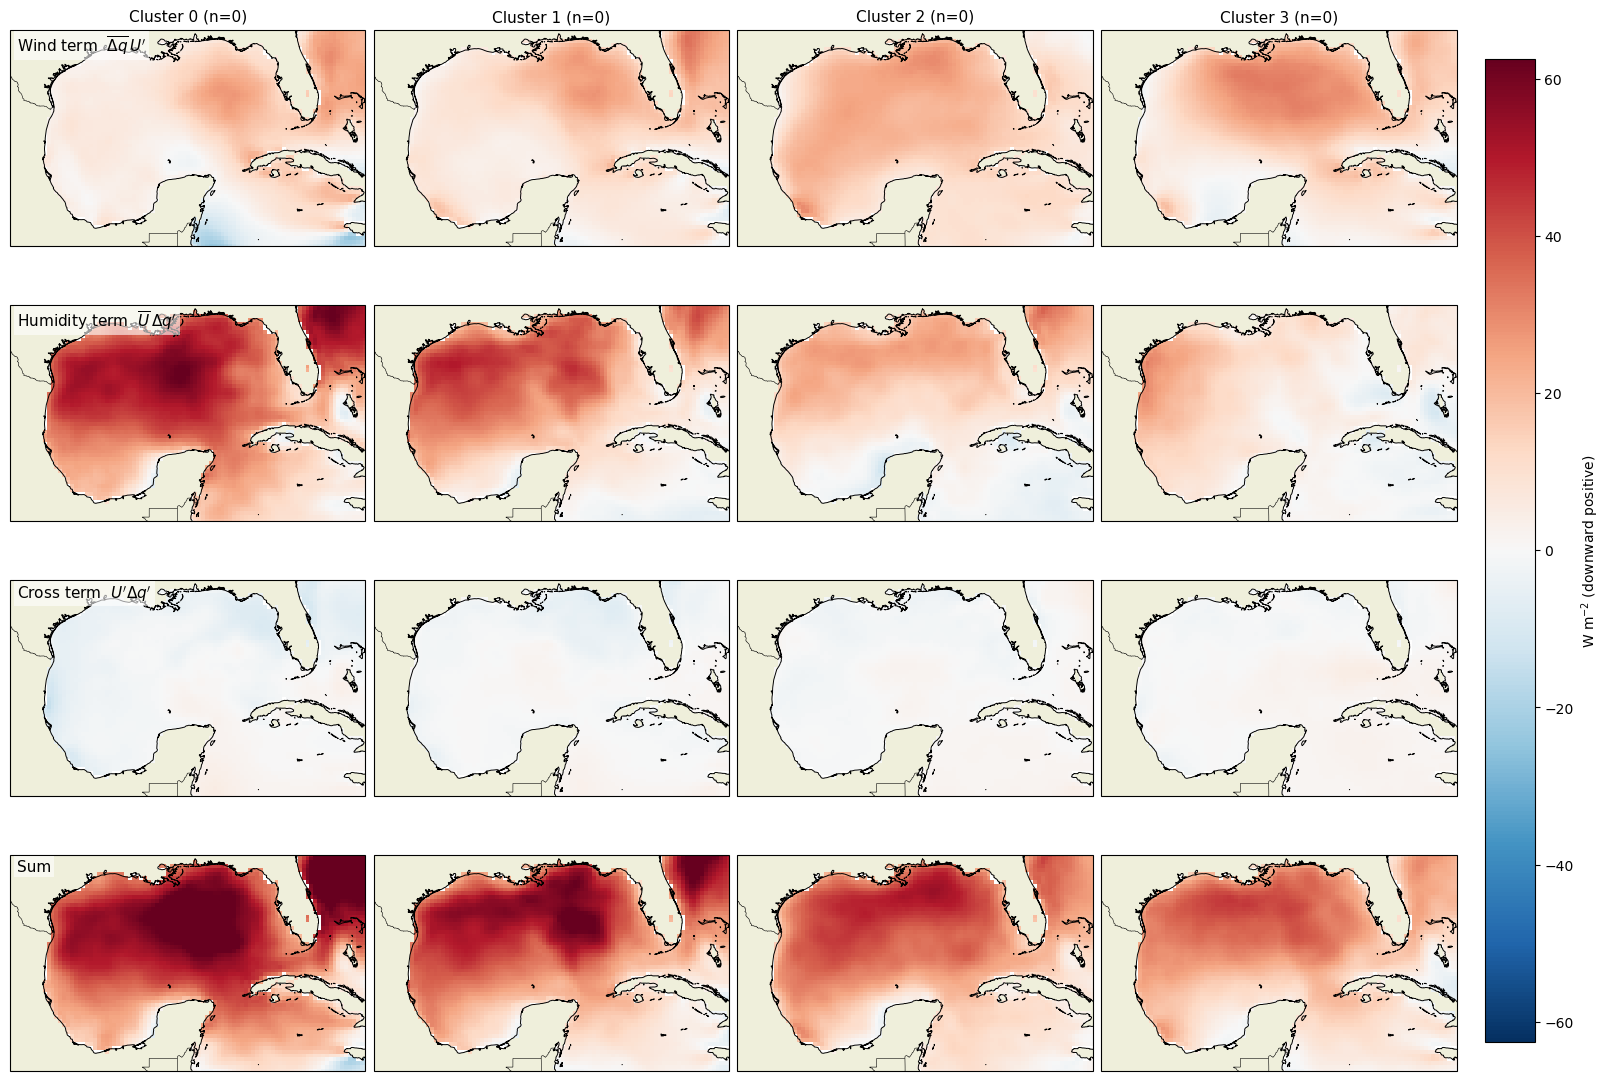

In [13]:
cl_dim = "cluster_label_K4"
clusters = np.sort(ds_cluster[cl_dim].values)
assert len(clusters) == 4, f"Expected 4 clusters, got {clusters}"

rows = [
    ("QL_U",   r"Wind term  $\overline{\Delta q}\,U'$"),
    ("QL_dq",  r"Humidity term  $\overline{U}\,\Delta q'$"),
    ("QL_NL",  r"Cross term  $U'\Delta q'$"),
    ("QL_sum", r"Sum"),
]

# global symmetric color limits across ALL panels (robust)
def global_robust_sym_limit(ds, varnames, q=0.99):
    all_abs = []
    for v in varnames:
        a = np.abs(ds[v].values).ravel()
        all_abs.append(a)
    all_abs = np.concatenate(all_abs)
    all_abs = all_abs[np.isfinite(all_abs)]
    vmax = np.quantile(all_abs, q) if all_abs.size else 1.0
    if (not np.isfinite(vmax)) or vmax == 0:
        vmax = np.nanmax(all_abs) if all_abs.size else 1.0
    return -vmax, vmax

vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v,_ in rows], q=0.99)

proj = ccrs.PlateCarree()
extent = [float(ds_cluster["lon"].min()), float(ds_cluster["lon"].max()),
          float(ds_cluster["lat"].min()), float(ds_cluster["lat"].max())]

fig, axs = plt.subplots(
    nrows=len(rows), ncols=len(clusters),
    figsize=(16, 11),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

mappable = None

for r, (vname, rtitle) in enumerate(rows):
    for c, cl in enumerate(clusters):
        ax = axs[r, c]
        da = ds_cluster[vname].sel({cl_dim: cl})

        im = ax.pcolormesh(
            ds_cluster["lon"], ds_cluster["lat"], da,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin, vmax=vmax,
            transform=proj
        )
        if mappable is None:
            mappable = im

        ax.set_extent(extent, crs=proj)
        ax.coastlines(linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.LAND, zorder=0)

        if r == 0:
            ne = ds_cluster["n_events"].sel({cl_dim: cl}).values
            ax.set_title(f"Cluster {int(cl)} (n={int(ne)})", fontsize=11)

        if c == 0:
            ax.text(
                0.02, 0.98, rtitle,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=11,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)
            )

cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", shrink=0.9, pad=0.02)
cbar.set_label("W m$^{-2}$ (downward positive)")

plt.show()


In [14]:
qs_anom, qs_trend, qs_resid = deseason_and_detrend_var_fast2(qs)
qa_anom, qa_trend, qa_resid = deseason_and_detrend_var_fast2(qa)

# sanity: dq_resid should equal qs_resid - qa_resid (up to tiny numerical diff)
dq_check = (qs_resid - qa_resid) - dq_resid
print("max| (qs_resid-qa_resid) - dq_resid | =", float(np.nanmax(np.abs(dq_check.values))))


[WARN] None: seasonal_climatology_fast2 returned empty or no 'doy' dimension, using xarray groupby fallback instead.
max| (qs_resid-qa_resid) - dq_resid | = 0.003263984341174364


In [15]:
# humidity term (already): QL_dq = SCALE * (U_bar * dq_resid)
# split into:
QL_qs = SCALE * (U_bar * qs_resid)          # K * Ubar * qs'
QL_qa = SCALE * (-U_bar * qa_resid)         # -K * Ubar * qa'  (note the minus)

# check exact closure of split (should match QL_dq very closely)
split_err = (QL_qs + QL_qa) - QL_dq
print("max| (QL_qs+QL_qa) - QL_dq | =", float(np.nanmax(np.abs(split_err.values))))


max| (QL_qs+QL_qa) - QL_dq | = 80.3704833984375


In [16]:
def mean_over_index_window(da, s, p):
    return da.isel(time=slice(s, p+1)).mean("time")

n_events = ev.dims["events"]
tlen = ds.dims["time"]

event_list2 = []
for i in range(n_events):
    s = int(idx_start_era5[i])
    p = int(idx_peak_era5[i])

    if (s < 0) or (p < 0) or (p < s) or (p >= tlen):
        template = QL_sum.isel(time=0) * np.nan
        event_list2.append(xr.Dataset({
            "QL_qs": template,
            "QL_qa": template,
        }))
        continue

    event_list2.append(xr.Dataset({
        "QL_qs": mean_over_index_window(QL_qs, s, p),
        "QL_qa": mean_over_index_window(QL_qa, s, p),
    }))

ds_event2 = xr.concat(event_list2, dim="events")
ds_event2 = ds_event2.assign_coords(cluster_label_K4=("events", ev["cluster_label_K4"].values))

ds_cluster2 = ds_event2.groupby("cluster_label_K4").mean("events")
ds_cluster2["n_events"] = ds_event2.groupby("cluster_label_K4").count()["QL_qs"].isel(lat=0, lon=0)

# merge with your existing ds_cluster for convenience
ds_cluster = xr.merge([ds_cluster, ds_cluster2], compat="override")
ds_cluster


/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1834246828.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_events = ev.dims["events"]
/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/1834246828.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tlen = ds.dims["time"]


<xarray.Dataset> Size: 680kB
Dimensions:             (cluster_label_K4: 4, lat: 57, lon: 93)
Coordinates:
    number              int64 8B 0
  * lat                 (lat) float64 456B 31.0 30.75 30.5 ... 17.5 17.25 17.0
  * lon                 (lon) float64 744B -100.0 -99.75 -99.5 ... -77.25 -77.0
  * cluster_label_K4    (cluster_label_K4) int32 16B 0 1 2 3
Data variables:
    QL_U                (cluster_label_K4, lat, lon) float32 85kB nan ... 0.6714
    QL_dq               (cluster_label_K4, lat, lon) float32 85kB nan ... -2.692
    QL_NL               (cluster_label_K4, lat, lon) float32 85kB nan ... 2.72
    QL_sum              (cluster_label_K4, lat, lon) float32 85kB nan ... 0.6986
    LH_resid            (cluster_label_K4, lat, lon) float32 85kB -8.699 ... ...
    n_events            (cluster_label_K4) int64 32B 0 0 0 0
    diff_LH_minus_bulk  (cluster_label_K4, lat, lon) float32 85kB nan ... -4.398
    QL_qs               (cluster_label_K4, lat, lon) float32 85kB nan ... -5.583
    QL_qa               (cluster_label_K4, lat, lon) float32 85kB 18.48 ... 2...

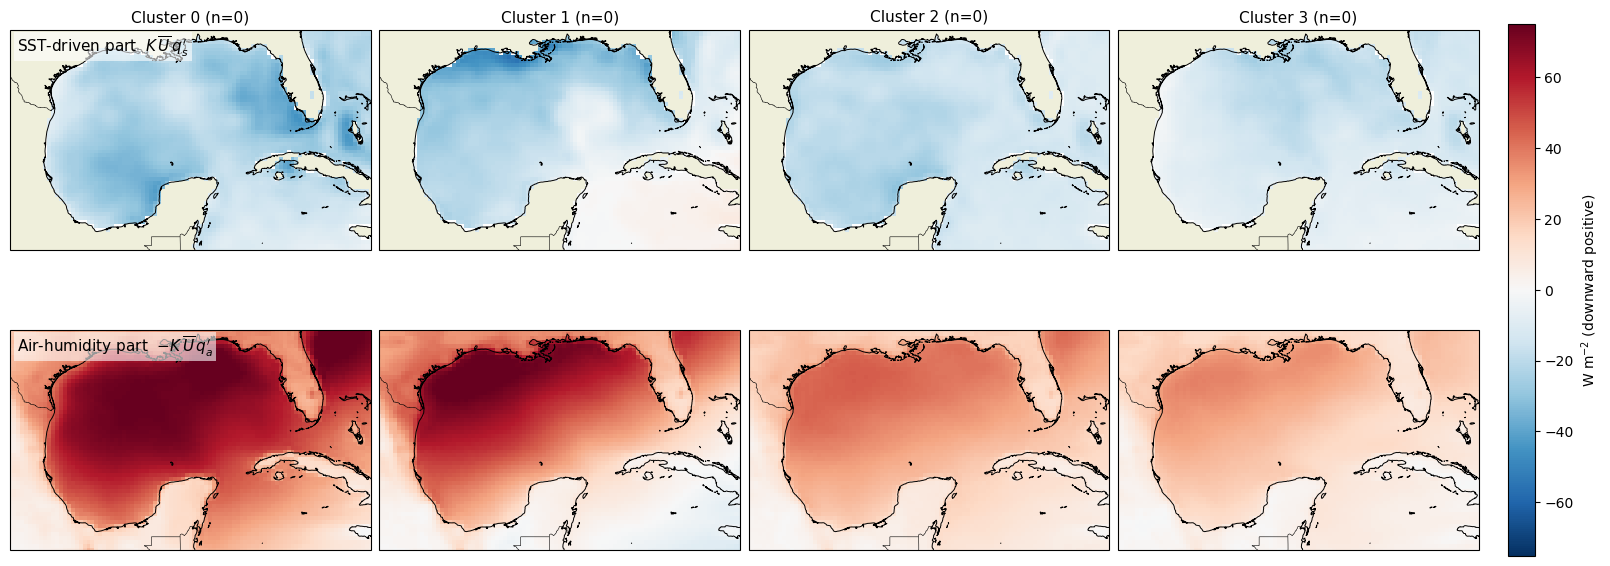

In [17]:
cl_dim = "cluster_label_K4"
clusters = np.sort(ds_cluster[cl_dim].values)

rows_src = [
    ("QL_qs", r"SST-driven part  $K\,\overline{U}\,q_s'$"),
    ("QL_qa", r"Air-humidity part  $-K\,\overline{U}\,q_a'$"),
]

# shared symmetric limits across both rows
def global_robust_sym_limit(ds, varnames, q=0.99):
    all_abs = []
    for v in varnames:
        a = np.abs(ds[v].values).ravel()
        all_abs.append(a)
    all_abs = np.concatenate(all_abs)
    all_abs = all_abs[np.isfinite(all_abs)]
    vmax = np.quantile(all_abs, q) if all_abs.size else 1.0
    if (not np.isfinite(vmax)) or vmax == 0:
        vmax = np.nanmax(all_abs) if all_abs.size else 1.0
    return -vmax, vmax

vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v,_ in rows_src], q=0.99)

proj = ccrs.PlateCarree()
extent = [float(ds_cluster["lon"].min()), float(ds_cluster["lon"].max()),
          float(ds_cluster["lat"].min()), float(ds_cluster["lat"].max())]

fig, axs = plt.subplots(
    nrows=len(rows_src), ncols=len(clusters),
    figsize=(16, 6),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

mappable = None
for r, (vname, rtitle) in enumerate(rows_src):
    for c, cl in enumerate(clusters):
        ax = axs[r, c]
        da = ds_cluster[vname].sel({cl_dim: cl})

        im = ax.pcolormesh(
            ds_cluster["lon"], ds_cluster["lat"], da,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin, vmax=vmax,
            transform=proj
        )
        if mappable is None:
            mappable = im

        ax.set_extent(extent, crs=proj)
        ax.coastlines(linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.LAND, zorder=0)

        if r == 0:
            ne = ds_cluster["n_events"].sel({cl_dim: cl}).values
            ax.set_title(f"Cluster {int(cl)} (n={int(ne)})", fontsize=11)

        if c == 0:
            ax.text(
                0.02, 0.98, rtitle,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=11,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)
            )

cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", shrink=0.9, pad=0.02)
cbar.set_label("W m$^{-2}$ (downward positive)")
plt.show()


In [18]:
for cl in np.sort(ds_cluster["cluster_label_K4"].values):
    qs_m = float(area_mean(ds_cluster["QL_qs"].sel(cluster_label_K4=cl)).values)
    qa_m = float(area_mean(ds_cluster["QL_qa"].sel(cluster_label_K4=cl)).values)
    dq_m = float(area_mean(ds_cluster["QL_dq"].sel(cluster_label_K4=cl)).values)

    # fraction by absolute contribution (avoid sign cancellation)
    denom = (abs(qs_m) + abs(qa_m)) if (abs(qs_m)+abs(qa_m))>0 else np.nan
    f_qs = abs(qs_m)/denom
    f_qa = abs(qa_m)/denom

    print(f"Cluster {int(cl)}: mean QL_dq={dq_m:.2f}, QL_qs={qs_m:.2f}, QL_qa={qa_m:.2f} | frac_abs: qs={f_qs:.2f}, qa={f_qa:.2f}")


Cluster 0: mean QL_dq=31.99, QL_qs=-22.62, QL_qa=42.94 | frac_abs: qs=0.34, qa=0.66
Cluster 1: mean QL_dq=19.38, QL_qs=-14.54, QL_qa=29.29 | frac_abs: qs=0.33, qa=0.67
Cluster 2: mean QL_dq=10.02, QL_qs=-16.38, QL_qa=22.28 | frac_abs: qs=0.42, qa=0.58
Cluster 3: mean QL_dq=6.14, QL_qs=-12.30, QL_qa=15.40 | frac_abs: qs=0.44, qa=0.56


In [19]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ============================================================
# 1. Read events / labels and swap label 1 <-> 2
# ============================================================
ev = xr.open_dataset(EVENTS_PATH)
lb = xr.open_dataset(LABELS_PATH)

n_ev = ev.dims["events"]
assert lb.dims["event"] == n_ev, "Label file event count != ev events count."

ev = ev.assign_coords(event_id=("events", np.arange(n_ev)))
lb2 = lb.rename({"event": "event_id"})

raw_labels = lb2["cluster_label_K4"].sel(event_id=ev["event_id"]).values
swapped_labels = raw_labels.copy()
swapped_labels[raw_labels == 1] = 2
swapped_labels[raw_labels == 2] = 1

ev = ev.assign_coords(
    cluster_label_K4=("events", swapped_labels)
)

# 如果后续也要直接用 lb2，顺手更新
lb2["cluster_label_K4"] = xr.DataArray(
    swapped_labels,
    dims=("event_id",),
    coords={"event_id": ev["event_id"].values}
)

# ============================================================
# 2. Plotting helpers
# ============================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8.0,
    "axes.titlesize": 8.8,
    "axes.labelsize": 8.0,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def panel_label_sequence(n):
    return [f"({chr(97 + i)})" for i in range(n)]

def add_panel_label(ax, text, x=0.02, y=0.98, fontsize=7.0):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.72
        ),
        zorder=10
    )

def add_map_labels(ax, show_left=False, show_bottom=False, extent=None, label_size=7.0):
    proj = ccrs.PlateCarree()

    if extent is None:
        xlocs = mticker.FixedLocator([-95, -90, -85, -80])
        ylocs = mticker.FixedLocator([20, 25, 30])
    else:
        lon_min, lon_max, lat_min, lat_max = extent
        xticks = np.arange(np.ceil(lon_min / 5) * 5, np.floor(lon_max / 5) * 5 + 1, 5)
        yticks = np.arange(np.ceil(lat_min / 5) * 5, np.floor(lat_max / 5) * 5 + 1, 5)
        xlocs = mticker.FixedLocator(xticks)
        ylocs = mticker.FixedLocator(yticks)

    gl = ax.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=0.28,
        color="0.6",
        alpha=0.40,
        linestyle="--",
        xlocs=xlocs,
        ylocs=ylocs,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = bool(show_left)
    gl.bottom_labels = bool(show_bottom)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": label_size}
    gl.ylabel_style = {"size": label_size}
    gl.xpadding = 1.5
    gl.ypadding = 1.5
    try:
        gl.rotate_labels = False
    except Exception:
        pass

def global_robust_sym_limit(ds, varnames, q=0.99):
    all_abs = []
    for v in varnames:
        a = np.abs(ds[v].values).ravel()
        all_abs.append(a)
    all_abs = np.concatenate(all_abs)
    all_abs = all_abs[np.isfinite(all_abs)]
    vmax = np.quantile(all_abs, q) if all_abs.size else 1.0
    if (not np.isfinite(vmax)) or vmax == 0:
        vmax = np.nanmax(all_abs) if all_abs.size else 1.0
    return -vmax, vmax


# ============================================================
# 3. Figure A: QL_U / QL_dq / QL_NL / QL_sum
# ============================================================
def plot_ql_decomp_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path=None,
):
    clusters = np.sort(ds_cluster[cl_dim].values)
    assert len(clusters) == 4, f"Expected 4 clusters, got {clusters}"

    rows = [
        ("QL_U",   r"Wind term  $\overline{\Delta q}\,U'$"),
        ("QL_dq",  r"Humidity term  $\overline{U}\,\Delta q'$"),
        ("QL_NL",  r"Cross term  $U'\Delta q'$"),
        ("QL_sum", r"Sum"),
    ]

    vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v, _ in rows], q=0.99)

    proj = ccrs.PlateCarree()
    extent = [
        float(ds_cluster["lon"].min()),
        float(ds_cluster["lon"].max()),
        float(ds_cluster["lat"].min()),
        float(ds_cluster["lat"].max()),
    ]

    nrows = len(rows)
    ncols = len(clusters)
    panel_labels = panel_label_sequence(nrows * ncols)

    fig, axs = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(7.2, 6.6),
        subplot_kw={"projection": proj},
        constrained_layout=False
    )
    axs = np.atleast_2d(axs)

    mappable = None

    for r, (vname, rtitle) in enumerate(rows):
        for c, cl in enumerate(clusters):
            ax = axs[r, c]
            da = ds_cluster[vname].sel({cl_dim: cl})

            im = ax.pcolormesh(
                ds_cluster["lon"], ds_cluster["lat"], da,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin, vmax=vmax,
                transform=proj
            )
            if mappable is None:
                mappable = im

            ax.set_extent(extent, crs=proj)
            ax.coastlines(linewidth=0.45)
            ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)

            if r == 0:
                ne = ds_cluster["n_events"].sel({cl_dim: cl}).values
                ax.set_title(
                    f"Type {c+1} (n={int(ne)})",
                    fontsize=8.8,
                    fontweight="semibold",
                    pad=2.5
                )

            add_panel_label(ax, panel_labels[r * ncols + c], fontsize=7.0)

            add_map_labels(
                ax,
                show_left=(c == 0),
                show_bottom=(r == nrows - 1),
                extent=extent,
                label_size=7.0
            )

    # row titles on the far left
    row_titles = [title for _, title in rows]
    for r, title in enumerate(row_titles):
        pos = axs[r, 0].get_position()
        fig.text(
            pos.x0 - 0.025,
            pos.y0 + pos.height / 2,
            title,
            ha="right",
            va="center",
            fontsize=8.4,
            fontweight="semibold"
        )

    fig.subplots_adjust(
        left=0.10, right=0.90,
        bottom=0.06, top=0.94,
        wspace=0.03, hspace=0.01
    )

    cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label(r"W m$^{-2}$ (downward positive)", fontsize=8.0)
    cbar.ax.tick_params(labelsize=7.0, width=0.5, length=2.2)
    cbar.outline.set_linewidth(0.6)

    plt.show()

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight", facecolor="white")


# ============================================================
# 4. Figure B: QL_qs / QL_qa
# ============================================================
def plot_ql_source_parts_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path=None,
):
    clusters = np.sort(ds_cluster[cl_dim].values)

    rows_src = [
        ("QL_qs", r"SST-driven part  $K\,\overline{U}\,q_s'$"),
        ("QL_qa", r"Air-humidity part  $-K\,\overline{U}\,q_a'$"),
    ]

    vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v, _ in rows_src], q=0.99)

    proj = ccrs.PlateCarree()
    extent = [
        float(ds_cluster["lon"].min()),
        float(ds_cluster["lon"].max()),
        float(ds_cluster["lat"].min()),
        float(ds_cluster["lat"].max()),
    ]

    nrows = len(rows_src)
    ncols = len(clusters)
    panel_labels = panel_label_sequence(nrows * ncols)

    fig, axs = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(7.2, 3.4),
        subplot_kw={"projection": proj},
        constrained_layout=False
    )
    axs = np.atleast_2d(axs)

    mappable = None

    for r, (vname, rtitle) in enumerate(rows_src):
        for c, cl in enumerate(clusters):
            ax = axs[r, c]
            da = ds_cluster[vname].sel({cl_dim: cl})

            im = ax.pcolormesh(
                ds_cluster["lon"], ds_cluster["lat"], da,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin, vmax=vmax,
                transform=proj
            )
            if mappable is None:
                mappable = im

            ax.set_extent(extent, crs=proj)
            ax.coastlines(linewidth=0.45)
            ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)

            if r == 0:
                ne = ds_cluster["n_events"].sel({cl_dim: cl}).values
                ax.set_title(
                    f"Type {c+1} (n={int(ne)})",
                    fontsize=8.8,
                    fontweight="semibold",
                    pad=2.5
                )

            add_panel_label(ax, panel_labels[r * ncols + c], fontsize=7.0)

            add_map_labels(
                ax,
                show_left=(c == 0),
                show_bottom=(r == nrows - 1),
                extent=extent,
                label_size=7.0
            )

    row_titles = [title for _, title in rows_src]
    for r, title in enumerate(row_titles):
        pos = axs[r, 0].get_position()
        fig.text(
            pos.x0 - 0.025,
            pos.y0 + pos.height / 2,
            title,
            ha="right",
            va="center",
            fontsize=8.4,
            fontweight="semibold"
        )

    fig.subplots_adjust(
        left=0.10, right=0.90,
        bottom=0.09, top=0.93,
        wspace=0.03, hspace=0.01
    )

    cbar = fig.colorbar(mappable, ax=axs, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label(r"W m$^{-2}$ (downward positive)", fontsize=8.0)
    cbar.ax.tick_params(labelsize=7.0, width=0.5, length=2.2)
    cbar.outline.set_linewidth(0.6)

    plt.show()

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight", facecolor="white")

/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/3101139531.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_ev = ev.dims["events"]
/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/3101139531.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert lb.dims["event"] == n_ev, "Label file event count != ev events count."


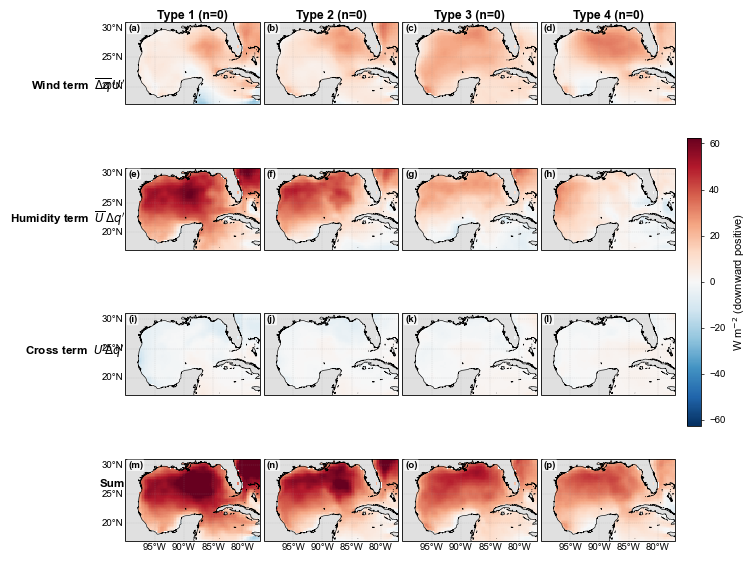

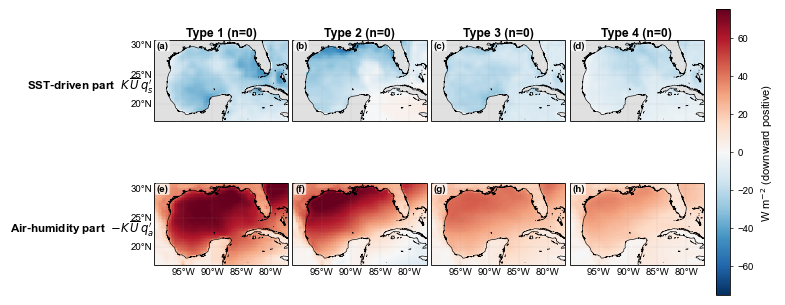

In [20]:
plot_ql_decomp_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    
)

plot_ql_source_parts_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    
)

In [21]:
DPI=600
def save_fig(fig, name_base, outdir="."):
    pdf_path = f"{outdir}/{name_base}.pdf"
    png_path = f"{outdir}/{name_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/2559535191.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_ev = ev.dims["events"]
/var/folders/fg/9b9hyhcj143_m75qvt409pp80000gp/T/ipykernel_10705/2559535191.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert lb.dims["event"] == n_ev, "Label file event count != ev events count."


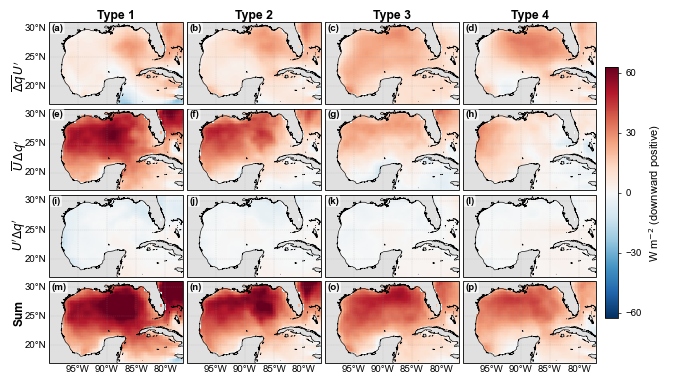

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig12_ql_decomp.pdf
Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig12_ql_decomp.png


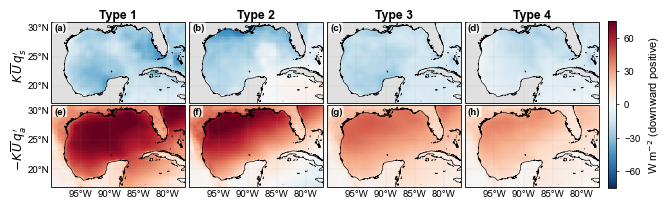

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig13_ql_source.pdf
Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig13_ql_source.png


In [24]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ============================================================
# 1. Read events / labels and swap label 1 <-> 2
# ============================================================
ev = xr.open_dataset(EVENTS_PATH)
lb = xr.open_dataset(LABELS_PATH)

n_ev = ev.dims["events"]
assert lb.dims["event"] == n_ev, "Label file event count != ev events count."

ev = ev.assign_coords(event_id=("events", np.arange(n_ev)))
lb2 = lb.rename({"event": "event_id"})

raw_labels = lb2["cluster_label_K4"].sel(event_id=ev["event_id"]).values
swapped_labels = raw_labels.copy()
swapped_labels[raw_labels == 1] = 2
swapped_labels[raw_labels == 2] = 1

ev = ev.assign_coords(
    cluster_label_K4=("events", swapped_labels)
)

# If you also use lb2 later, update it too
lb2["cluster_label_K4"] = xr.DataArray(
    swapped_labels,
    dims=("event_id",),
    coords={"event_id": ev["event_id"].values}
)

# ============================================================
# 2. Global plot style
# ============================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8.0,
    "axes.titlesize": 8.8,
    "axes.labelsize": 8.0,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# 3. Helpers
# ============================================================
def panel_label_sequence(n):
    return [f"({chr(97 + i)})" for i in range(n)]

def add_panel_label(ax, text, x=0.02, y=0.98, fontsize=7.0):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.72
        ),
        zorder=10
    )

def add_map_labels(ax, show_left=False, show_bottom=False, extent=None, label_size=7.0):
    proj = ccrs.PlateCarree()

    if extent is None:
        xlocs = mticker.FixedLocator([-95, -90, -85, -80])
        ylocs = mticker.FixedLocator([20, 25, 30])
    else:
        lon_min, lon_max, lat_min, lat_max = extent
        xticks = np.arange(np.ceil(lon_min / 5) * 5, np.floor(lon_max / 5) * 5 + 1, 5)
        yticks = np.arange(np.ceil(lat_min / 5) * 5, np.floor(lat_max / 5) * 5 + 1, 5)
        xlocs = mticker.FixedLocator(xticks)
        ylocs = mticker.FixedLocator(yticks)

    gl = ax.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=0.28,
        color="0.6",
        alpha=0.40,
        linestyle="--",
        xlocs=xlocs,
        ylocs=ylocs,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = bool(show_left)
    gl.bottom_labels = bool(show_bottom)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": label_size}
    gl.ylabel_style = {"size": label_size}
    gl.xpadding = 1.5
    gl.ypadding = 1.5
    try:
        gl.rotate_labels = False
    except Exception:
        pass

def global_robust_sym_limit(ds, varnames, q=0.99):
    all_abs = []
    for v in varnames:
        a = np.abs(ds[v].values).ravel()
        all_abs.append(a)
    all_abs = np.concatenate(all_abs)
    all_abs = all_abs[np.isfinite(all_abs)]
    vmax = np.quantile(all_abs, q) if all_abs.size else 1.0
    if (not np.isfinite(vmax)) or vmax == 0:
        vmax = np.nanmax(all_abs) if all_abs.size else 1.0
    return -vmax, vmax

# ============================================================
# 4. Figure A: QL_U / QL_dq / QL_NL / QL_sum
# ============================================================
def plot_ql_decomp_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path=None,
):
    clusters = np.sort(ds_cluster[cl_dim].values)
    assert len(clusters) == 4, f"Expected 4 clusters, got {clusters}"

    rows = [
        ("QL_U",   r"$\overline{\Delta q}\,U'$"),
        ("QL_dq",  r"$\overline{U}\,\Delta q'$"),
        ("QL_NL",  r"$U'\Delta q'$"),
        ("QL_sum", "Sum"),
    ]

    vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v, _ in rows], q=0.99)

    proj = ccrs.PlateCarree()
    extent = [
        float(ds_cluster["lon"].min()),
        float(ds_cluster["lon"].max()),
        float(ds_cluster["lat"].min()),
        float(ds_cluster["lat"].max()),
    ]

    nrows = len(rows)
    ncols = len(clusters)
    panel_labels = panel_label_sequence(nrows * ncols)

    fig, axs = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(7.2, 0.98 * nrows),
        subplot_kw={"projection": proj},
        constrained_layout=False
    )
    axs = np.atleast_2d(axs)

    mappable = None

    for r, (vname, _) in enumerate(rows):
        for c, cl in enumerate(clusters):
            ax = axs[r, c]
            da = ds_cluster[vname].sel({cl_dim: cl})

            im = ax.pcolormesh(
                ds_cluster["lon"], ds_cluster["lat"], da,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin, vmax=vmax,
                transform=proj
            )
            if mappable is None:
                mappable = im

            ax.set_extent(extent, crs=proj)
            ax.coastlines(linewidth=0.45)
            ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)

            if r == 0:
                ax.set_title(
                    f"Type {c+1}",
                    fontsize=8.8,
                    fontweight="semibold",
                    pad=2.5
                )

            add_panel_label(ax, panel_labels[r * ncols + c], fontsize=7.0)

            add_map_labels(
                ax,
                show_left=(c == 0),
                show_bottom=(r == nrows - 1),
                extent=extent,
                label_size=7.0
            )

    # vertical row labels
    row_titles = [title for _, title in rows]
    for r, title in enumerate(row_titles):
        pos = axs[r, 0].get_position()
        fig.text(
            pos.x0 - 0.065,
            pos.y0 + pos.height / 2,
            title,
            rotation=90,
            ha="center",
            va="center",
            fontsize=8.7,
            fontweight="semibold"
        )

    fig.subplots_adjust(
        left=0.11, right=0.90,
        bottom=0.06, top=0.94,
        wspace=0.03, hspace=0.005
    )

    cbar = fig.colorbar(
        mappable, ax=axs,
        orientation="vertical",
        fraction=0.022,
        pad=0.015
    )
    cbar.set_label(r"W m$^{-2}$ (downward positive)", fontsize=8.0)
    cbar.set_ticks([-60, -30, 0, 30, 60])
    cbar.ax.tick_params(labelsize=7.0, width=0.5, length=2.2)
    cbar.outline.set_linewidth(0.6)

    plt.show()

    if save_path is not None:
        save_fig(fig, "Fig12_ql_decomp", outdir=save_path)


# ============================================================
# 5. Figure B: QL_qs / QL_qa
# ============================================================
def plot_ql_source_parts_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path=None,
):
    clusters = np.sort(ds_cluster[cl_dim].values)

    rows_src = [
        ("QL_qs", r"$K\,\overline{U}\,q_s'$"),
        ("QL_qa", r"$-K\,\overline{U}\,q_a'$"),
    ]

    vmin, vmax = global_robust_sym_limit(ds_cluster, [v for v, _ in rows_src], q=0.99)

    proj = ccrs.PlateCarree()
    extent = [
        float(ds_cluster["lon"].min()),
        float(ds_cluster["lon"].max()),
        float(ds_cluster["lat"].min()),
        float(ds_cluster["lat"].max()),
    ]

    nrows = len(rows_src)
    ncols = len(clusters)
    panel_labels = panel_label_sequence(nrows * ncols)

    fig, axs = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(7.2, 0.98 * nrows),
        subplot_kw={"projection": proj},
        constrained_layout=False
    )
    axs = np.atleast_2d(axs)

    mappable = None

    for r, (vname, _) in enumerate(rows_src):
        for c, cl in enumerate(clusters):
            ax = axs[r, c]
            da = ds_cluster[vname].sel({cl_dim: cl})

            im = ax.pcolormesh(
                ds_cluster["lon"], ds_cluster["lat"], da,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin, vmax=vmax,
                transform=proj
            )
            if mappable is None:
                mappable = im

            ax.set_extent(extent, crs=proj)
            ax.coastlines(linewidth=0.45)
            ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)

            if r == 0:
                ax.set_title(
                    f"Type {c+1}",
                    fontsize=8.8,
                    fontweight="semibold",
                    pad=2.5
                )

            add_panel_label(ax, panel_labels[r * ncols + c], fontsize=7.0)

            add_map_labels(
                ax,
                show_left=(c == 0),
                show_bottom=(r == nrows - 1),
                extent=extent,
                label_size=7.0
            )

    # vertical row labels
    row_titles = [title for _, title in rows_src]
    for r, title in enumerate(row_titles):
        pos = axs[r, 0].get_position()
        fig.text(
            pos.x0 - 0.065,
            pos.y0 + pos.height / 2,
            title,
            rotation=90,
            ha="center",
            va="center",
            fontsize=8.7,
            fontweight="semibold"
        )

    fig.subplots_adjust(
        left=0.11, right=0.90,
        bottom=0.08, top=0.93,
        wspace=0.03, hspace=0.005
    )

    cbar = fig.colorbar(
        mappable, ax=axs,
        orientation="vertical",
        fraction=0.022,
        pad=0.015
    )
    cbar.set_label(r"W m$^{-2}$ (downward positive)", fontsize=8.0)
    cbar.set_ticks([-60, -30, 0, 30, 60])
    cbar.ax.tick_params(labelsize=7.0, width=0.5, length=2.2)
    cbar.outline.set_linewidth(0.6)

    plt.show()

    if save_path is not None:
        save_fig(fig, "Fig13_ql_source", outdir=save_path)



# ============================================================
# 6. Run
# ============================================================
plot_ql_decomp_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path="/Users/luty8/Documents/TAMU/agu25/fig"
)

plot_ql_source_parts_journal(
    ds_cluster,
    cl_dim="cluster_label_K4",
    save_path="/Users/luty8/Documents/TAMU/agu25/fig"
)